### This is the official Document made along the way to make this House prediction Model Using Linear Regression . this Notebok contians all the errors and Challenges faced Along the way to make the project

In [1]:
# Usual Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,12,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
1022,1023,50,RM,52.0,9439,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,87000
1218,1219,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,80500
544,545,60,RL,58.0,17104,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,New,Partial,179665
1143,1144,20,RL,NaN,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,80000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 1. Dealing with Missing Values

In [5]:
# All Missing Columns
missing_cols = (
    df
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda x:x>0]
)
print("Shape-> ",missing_cols.shape)
missing_cols

Shape->  (19,)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# Categorical Missing Columns
cat_missing_cols = (
    df.select_dtypes(include='object')
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda x:x>0]
)
print("Shape-> ",cat_missing_cols.shape)
cat_missing_cols

Shape->  (16,)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageFinish      81
GarageQual        81
GarageType        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtQual          37
BsmtCond          37
Electrical         1
dtype: int64

#### Soution :
1. `['PoolQC','FireplaceQu','GarageQual','GarageCond','BsmtQual','BsmtCond']` belongs to same category where `NaN => No attribute`
    - Ex	->  Excellent
    - Gd	->  Good
    - TA	->  Typical/Average
    - Fa	->  Fair
    - Po	->  Poor
    - NA	->  No Feature (atrribute is absent)

2. `['BsmtFinType1','BsmtFinType2']` belongs to same category where `NaN => No attribute`
    - GLQ	->  Good Living Quarters
    - ALQ	->  Average Living Quarters
    - BLQ	->  Below Average Living Quarters
    - Rec	->  Average Rec Room
    - LwQ	->  Low Quality
    - Unf	->  Unfinshed
    - NA	->  No Basement

3. Features where `NaN` => Not a feature or no attribute are `['MiscFeature','Alley','Fence','MasVnrType','GarageFinish','GarageType']`

4. `Electrical` has 1 NaN value , so filling it with global mode is suitable
5. `BsmtExposure` has
    - 'No' -> No Exposure
    - 'NA' -> No Basement  
    - so NaN => NA (no basement)  so it comes under point - 3

In [7]:
df['BsmtExposure'].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [8]:
df[cat_missing_cols.index].sample(10)

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,GarageFinish,GarageQual,GarageType,GarageCond,BsmtFinType2,BsmtExposure,BsmtFinType1,BsmtQual,BsmtCond,Electrical
464,NaN,NaN,NaN,NaN,BrkFace,NaN,NaN,NaN,NaN,NaN,Unf,No,Rec,Gd,TA,SBrkr
944,NaN,NaN,NaN,NaN,BrkFace,Gd,RFn,TA,Basment,TA,Rec,No,GLQ,TA,TA,FuseA
577,NaN,NaN,NaN,NaN,BrkFace,Fa,RFn,TA,Attchd,TA,ALQ,Av,LwQ,TA,TA,SBrkr
197,Ex,NaN,NaN,GdPrv,NaN,Ex,Unf,TA,Detchd,TA,LwQ,No,GLQ,TA,TA,SBrkr
211,NaN,NaN,NaN,NaN,NaN,NaN,RFn,TA,Attchd,TA,Unf,Mn,GLQ,Gd,TA,SBrkr
852,NaN,NaN,NaN,MnPrv,NaN,Gd,Unf,TA,Detchd,TA,Unf,No,Rec,TA,TA,SBrkr
1098,NaN,NaN,NaN,NaN,NaN,NaN,Unf,TA,Detchd,TA,Unf,No,BLQ,TA,TA,SBrkr
465,NaN,NaN,NaN,NaN,BrkFace,TA,Fin,TA,Attchd,TA,Unf,No,Unf,Gd,TA,SBrkr
874,NaN,NaN,NaN,NaN,NaN,NaN,Unf,TA,Detchd,TA,Unf,No,Unf,TA,TA,SBrkr
568,NaN,NaN,NaN,NaN,NaN,Gd,Fin,Gd,BuiltIn,TA,Unf,Gd,GLQ,Gd,TA,SBrkr


In [9]:
# Numerical Missing Columns
num_missing_cols = (
    df.select_dtypes(include=['int','float'])
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda x:x>0]
)
print("Shape-> ",num_missing_cols.shape)
num_missing_cols

Shape->  (3,)


LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

1. `LotFrontage` --> Fill with median of LotFrontage , by grouping the neigbour
2. `GarageYrBlt` -->
    - WARNING for Linear Regression: Filling with 0 creates a massive outlier (Year 0 vs Year 2000).
    - Better approach: Fill with 0, but create a "HasGarage" feature later to help the model.
    - Then Remove this GarageYrBlt or (just fill it with house built year)
3. `MasVnrArea` --> fill with zero , i dont have really gd idea but fillinng with zero looks good

In [10]:
df[num_missing_cols.index].sample(10)

,LotFrontage,GarageYrBlt,MasVnrArea
188,64.0,1979.0,275.0
758,24.0,1999.0,360.0
391,71.0,2001.0,0.0
1211,152.0,1988.0,0.0
1226,86.0,2007.0,74.0
1200,71.0,1972.0,0.0
236,65.0,2004.0,98.0
692,42.0,1989.0,293.0
337,70.0,2002.0,113.0
1313,108.0,1999.0,165.0


- The dtype of feature `MSSubClass` is int , but it has categorical data in int form -> conver into str then label it among nominal data

In [11]:
df['MSSubClass'] = df['MSSubClass'].astype(str)
df['MoSold']     = df['MoSold'].astype(str)

In [12]:
df['HasGarage'] = (df['GarageType'].notna()).astype(int)

Total living area has a very strong linear relationship with *SalePrice*

In [13]:
df['TotalSFArea'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

In [14]:
# # 1. Total Bathrooms (combining full and half baths from all floors)
# df['TotalBaths'] = (df['FullBath'] + (0.5 * df['HalfBath']) + 
#                     df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

# # 2. Was the house remodeled? (Binary: 1 if remodeled, 0 if not)
# df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

# # 3. Total Porch Area (combining all outdoor living space)
# df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']

# # NOTE: Remember to add 'TotalBaths', 'IsRemodeled', and 'TotalPorchSF' 
# # to your `numerical_cols` bucket so the pipeline scales them!

In [15]:
# # Drop massive outliers that confuse Linear models
# df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)
# df = df.reset_index(drop=True)

### 1. Split The Data -> To Avoid Data Leakage

Cast pseudo-categoricals BEFORE split

In [16]:
from sklearn.model_selection import train_test_split

# seprate target & features
X = df.drop(columns=['SalePrice','Id'])
Y = df['SalePrice']

# Split: 80% Train , 20% Validate
x_train,x_val,y_train,y_val = train_test_split(X,Y,test_size=0.2,random_state=42)

### 2. Define Column into different buckets based on analysis,for imputaition & encoding purposes etc.

##### BUCKET 1: Ordinal (Order matters - Needs OrdinalEncoder)

In [17]:
# Ordinal: order matters, encode with OrdinalEncoder using explicit categories
QUALITY_SCALE  = ['Po', 'Fa', 'TA', 'Gd', 'Ex']         # standard 5-level scale
QUALITY_SCALE_NA = ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'] # same + NA = absent

In [18]:
ordinal_cols_with_na = {
    # col                  : ordered categories (low → high)
    'ExterQual'   : QUALITY_SCALE,
    'ExterCond'   : QUALITY_SCALE,
    'HeatingQC'   : QUALITY_SCALE,
    'KitchenQual' : QUALITY_SCALE,
    'BsmtQual'    : QUALITY_SCALE_NA,
    'BsmtCond'    : QUALITY_SCALE_NA,
    'FireplaceQu' : QUALITY_SCALE_NA,
    'GarageQual'  : QUALITY_SCALE_NA,
    'GarageCond'  : QUALITY_SCALE_NA,
    'PoolQC'      : ['NA', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtExposure': ['NA', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Functional'  : ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'GarageFinish': ['NA', 'Unf', 'RFn', 'Fin'],
    'LotShape'    : ['IR3', 'IR2', 'IR1', 'Reg'],
    'LandSlope'   : ['Sev', 'Mod', 'Gtl'],
    'PavedDrive'  : ['N', 'P', 'Y'],
    # Already in Order :
    # 'OverallQual': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    # 'OverallCond': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
}

ordinal_cols = list(ordinal_cols_with_na.keys())

##### BUCKET 2: Nominal (No order - Needs OneHotEncoder)

In [19]:
# Nominal: no order, encode with OneHotEncoder
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
    'Heating', 'CentralAir', 'Electrical', 'GarageType',
    'Fence', 'MiscFeature', 'SaleType', 'SaleCondition',
    'MSSubClass', 'MoSold',  # originally int, cast above
]

##### BUCKET 3: Numerical (Needs Scaling)

In [20]:
# Numerical: scale with StandardScaler / RobustScaler
numerical_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageCars', 'GarageArea',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
    'YrSold','OverallQual',
    'OverallCond','TotalSFArea',
    # HasGarage is binary (0/1) — StandardScaler handles it fine for linear regression
'HasGarage',
# 'TotalBaths', 'IsRemodeled','TotalPorchSF'
]

In [21]:
# Temporal: treat separately (year-based features — consider age engineering)
temporal_cols = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

In [22]:
# df.shape[1] - (len(ordinal_cols) + len(nominal_cols) + len(numerical_cols)) # this 2 are saleprice & id cols
X.shape[1] - (len(ordinal_cols) + len(nominal_cols) + len(numerical_cols) + len(temporal_cols))

0

In [23]:
# Sanity check — should be 0
# all_grouped = set(ordinal_cols + nominal_cols + numerical_cols + temporal_cols)
# assert all_grouped == set(X.columns), f"Ungrouped cols: {set(X.columns) - all_grouped}"

In [24]:
set(X.columns) - set(ordinal_cols + nominal_cols + numerical_cols + temporal_cols)

set()

### 3. Making Pipeline

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler,FunctionTransformer

In [26]:
# Ordinal pipeline: fill NA string -> encode in order
ordinal_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='NA')),
    ('encode',OrdinalEncoder(
        categories=[ordinal_cols_with_na[c] for c in ordinal_cols],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
# this does takes all the oridinal cols , if any cols has NaN fills with str 'NA'
# then it does the encoding from 0 to class.items() - 1 in each clos

In [27]:
# Quick sanity check before building the full pipeline
for col, cats in ordinal_cols_with_na.items():
    actual_vals = set(df[col].dropna().unique())
    defined_vals = set(cats) - {'NA'}  # exclude NA placeholder

    missing_from_def = actual_vals - defined_vals
    if missing_from_def:
        print(f"⚠️  {col}: values in data not in your categories: {missing_from_def}")
    else:
        print(f"✅  {col}: OK")

✅  ExterQual: OK
✅  ExterCond: OK
✅  HeatingQC: OK
✅  KitchenQual: OK
✅  BsmtQual: OK
✅  BsmtCond: OK
✅  FireplaceQu: OK
✅  GarageQual: OK
✅  GarageCond: OK
✅  PoolQC: OK
✅  BsmtExposure: OK
✅  BsmtFinType1: OK
✅  BsmtFinType2: OK
✅  Functional: OK
✅  GarageFinish: OK
✅  LotShape: OK
✅  LandSlope: OK
✅  PavedDrive: OK


In [28]:
# Nominal pipeline: fill NA string -> one-hot
nominal_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='NA')),
    ('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

In [29]:
# Numerical pipeline: median impute → scale
numerical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])


In [30]:
# Temporal: convert to "age" instead of raw year, then scale
temporal_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('to_age', FunctionTransformer(lambda X: 2010 - X)),  # age at time of dataset
    ('scale',  StandardScaler()),
])

In [31]:
# LotFrontage is handled separately by NeighborhoodMedianImputer
numerical_cols_no_lot = [c for c in numerical_cols if c != 'LotFrontage']

In [32]:
from sklearn.base import BaseEstimator, TransformerMixin

class NeighborhoodMedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=['LotFrontage', 'Neighborhood'])
        self.medians_ = df.groupby('Neighborhood')['LotFrontage'].median()
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=['LotFrontage', 'Neighborhood']).copy()
        mask = df['LotFrontage'].isna()
        df.loc[mask, 'LotFrontage'] = df.loc[mask, 'Neighborhood'].map(self.medians_)
        return df[['LotFrontage']].values

In [33]:
lotfrontage_pipe = Pipeline([
    ('impute', NeighborhoodMedianImputer()),
    ('scale',  StandardScaler()),
])

In [34]:
preprocessor = ColumnTransformer([
    ('lot_frontage', lotfrontage_pipe,        ['LotFrontage', 'Neighborhood']),
    ('ord',          ordinal_pipe,            ordinal_cols),
    ('nom',          nominal_pipe,            nominal_cols),
    ('num',          numerical_pipe,          numerical_cols_no_lot),
    ('tmp',          temporal_pipe,           temporal_cols),
], remainder='drop')

1. Attach a model to the preprocessor in a full pipeline

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
import numpy as np

# 1. Wrap the Linear Regression model to automatically log-transform the target
log_target_model = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log1p,       # Applies log(1 + x) during training
    inverse_func=np.expm1 # Reverses transformation to real dollars for predictions
)

# 2. Attach it to your existing preprocessor
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', log_target_model)
])

2. Fit on training data

In [36]:
full_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('lot_frontage', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

3. Evaluate on validation data

In [40]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Adjusted R2 on the TRAINING set
train_preds = full_pipeline.predict(x_train)
train_r2 = r2_score(y_train, train_preds)

# n for training set
n_train = len(y_train)
# Extract the preprocessor from the pipeline and transform X_val to see its final shape
X_val_transformed = full_pipeline.named_steps['preprocessor'].transform(x_val)
p = X_val_transformed.shape[1] 

# Calculate it!
train_adj_r2 = 1 - ((1 - train_r2) * (n_train - 1) / (n_train - p - 1))

print(f"Training R2       : {train_r2:.4f}")
print(f"Training Adj R2   : {train_adj_r2:.4f}")

Training R2       : 0.9456
Training Adj R2   : 0.9303


In [42]:
print(n_train)
print(p)

1168
256


In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = full_pipeline.predict(x_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2   = r2_score(y_val, y_pred)

# Adjusted R-Squared
# We need 'n' (number of samples) and 'p' (number of features AFTER encoding)
n = len(y_val)

# Extract the preprocessor from the pipeline and transform X_val to see its final shape
X_val_transformed = full_pipeline.named_steps['preprocessor'].transform(x_val)
p = X_val_transformed.shape[1] 

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"RMSE : {rmse:,.0f}")
print(f"R²   : {r2:.4f}")
print(f"Adj R²   : {adj_r2:.4f}")


RMSE : 22,832
R²   : 0.9320
Adj R²   : 0.4349


In [45]:
print(n)
print(p)

292
256


4. Check residuals — important for linear regression

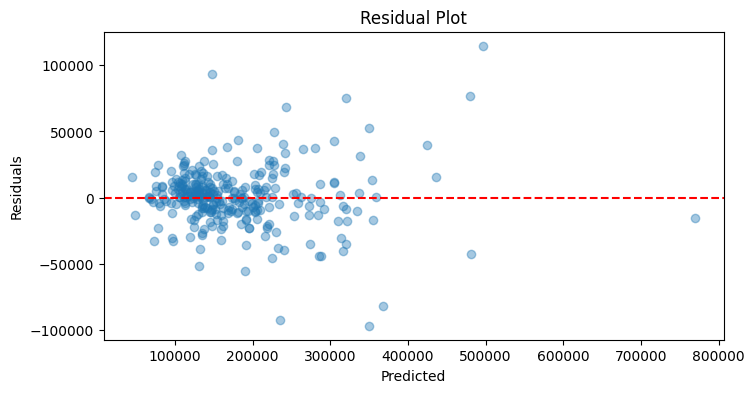

In [39]:
residuals = y_val - y_pred

plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

5. Log transform SalePrice if residuals show a funnel